<a href="https://colab.research.google.com/github/fadlizaenalaripin/analisis-btc-5-tahun-terakhir/blob/main/btc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bagian data cleaning


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving BTC-USD.csv to BTC-USD.csv


In [ ]:
import pandas as pd

# Load data
df = pd.read_csv("BTC-USD.csv")

# Convert kolom 'Date' jadi datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter dari 1 Jan 2019 sampai 31 Des 2024
df_filtered = df[(df['Date'] >= '2019-01-01') & (df['Date'] <= '2024-12-31')].copy()  # Tambahkan .copy() di sini

# Tambahkan kolom bantu menggunakan .loc[]
df_filtered.loc[:, 'Year'] = df_filtered['Date'].dt.year
df_filtered.loc[:, 'Month'] = df_filtered['Date'].dt.month
df_filtered.loc[:, 'YearMonth'] = df_filtered['Date'].dt.to_period('M').astype(str)  # format 'YYYY-MM'

# Simpan hasilnya ke file baru
df_filtered.to_csv("BTC_2019_2024_clean.csv", index=False)

# Tampilkan 5 baris awal
df_filtered.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,YearMonth
1567,2019-01-01,3746.713379,3850.913818,3707.231201,3843.520020,3843.520020,4324200990,2019,1,2019-01
1568,2019-01-02,3849.216309,3947.981201,3817.409424,3943.409424,3943.409424,5244856836,2019,1,2019-01
1569,2019-01-03,3931.048584,3935.685059,3826.222900,3836.741211,3836.741211,4530215219,2019,1,2019-01
1570,2019-01-04,3832.040039,3865.934570,3783.853760,3857.717529,3857.717529,4847965467,2019,1,2019-01
1571,2019-01-05,3851.973877,3904.903076,3836.900146,3845.194580,3845.194580,5137609824,2019,1,2019-01


In [ ]:
# mengecek missing value
df_filtered.isnull().sum()

# mengecek duplikat baris
df_filtered.duplicated().sum()

np.int64(0)

In [ ]:
# memastikan data terurut berdasarkan tanggal
filtered_df = df_filtered.sort_values(by='Date')

# mengecek tipe data kolom
print(df_filtered.dtypes)

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
Year                  int32
Month                 int32
YearMonth            object
dtype: object


In [ ]:
files.download("BTC_2019_2024_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## bangian analisis statistik deskritif

In [ ]:
# Menghitung statistik deskriptif untuk memberikan gambaran umum tentang data,
# seperti rata-rata, nilai maksimum, minimum, dsb
df_filtered.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month
count,1873,1873.000000,1873.000000,1873.000000,1873.000000,1873.000000,1.873000e+03,1873.000000,1873.000000
mean,2021-07-25 00:00:00,25061.641235,25628.506640,24460.973374,25085.128814,25085.128814,2.896644e+10,2021.074746,6.393486
min,2019-01-01 00:00:00,3401.376465,3427.945557,3391.023682,3399.471680,3399.471680,4.324201e+09,2019.000000,1.000000
25%,2020-04-13 00:00:00,9756.786133,9938.297852,9589.743164,9757.970703,9757.970703,1.713058e+10,2020.000000,3.000000
50%,2021-07-25 00:00:00,22840.796875,23282.347656,22430.605469,22846.507813,22846.507813,2.563548e+10,2021.000000,6.000000
75%,2022-11-05 00:00:00,37748.011719,38856.968750,36773.667969,37784.332031,37784.332031,3.620089e+10,2022.000000,9.000000
max,2024-02-16 00:00:00,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11,2024.000000,12.000000
std,NaN,16162.112319,16567.973808,15701.295391,16162.376743,16162.376743,1.799846e+10,1.473327,3.501907


In [ ]:
# Menampilkan rata-rata dari harga pembukaan, harga tertinggi, harga terendah,
# harga penutupan, dan harga penutupan yang disesuaikan
df_filtered[['Open', 'High', 'Low', 'Close', 'Adj Close']].mean()

,0
Open,25061.641235
High,25628.506640
Low,24460.973374
Close,25085.128814
Adj Close,25085.128814


In [ ]:
 # Menampilkan harga tertinggi dari kolom-kolom yang terkait dengan harga
df_filtered[['Open', 'High', 'Low', 'Close', 'Adj Close']].max()

,0
Open,67549.734375
High,68789.625000
Low,66382.062500
Close,67566.828125
Adj Close,67566.828125


In [ ]:
# Menampilkan harga terendah dari kolom-kolom yang terkait dengan harga
df_filtered[['Open', 'High', 'Low', 'Close', 'Adj Close']].min()

,0
Open,3401.376465
High,3427.945557
Low,3391.023682
Close,3399.471680
Adj Close,3399.471680


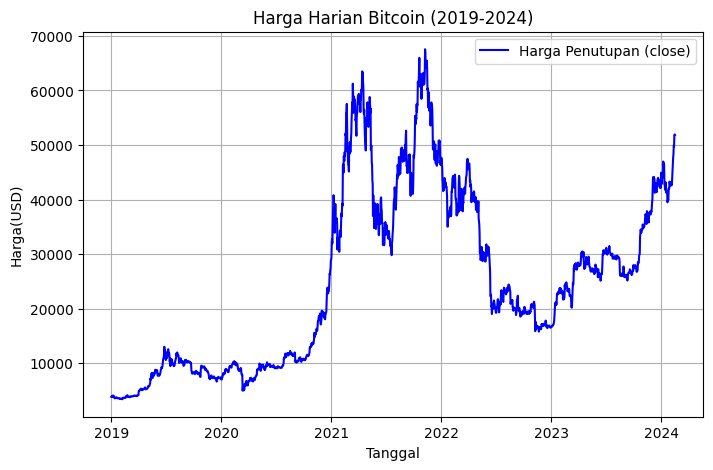

In [ ]:
import matplotlib.pyplot as plt

# Membuat grafik harga penutupan Bitcoin (Close) dari tanggal yang sudah difilter
plt.figure(figsize=(8, 5)) # Ukuran Plot
plt.plot(df_filtered['Date'], df_filtered['Close'], label='Harga Penutupan (close)', color='blue')
plt.title('Harga Harian Bitcoin (2019-2024)') #Judul Grafik
plt.xlabel('Tanggal') # Label Sumbu X
plt.ylabel('Harga(USD)') # Label Sumbu Y
plt.legend()  # Menampilkan legenda untuk garis
plt.grid(True)  # Menambahkan grid untuk kemudahan visualisasi
plt.show()  # Menampilkan grafik

In [ ]:
# Menggunakan .loc untuk menambahkan kolom 'Year' agar menghindari SettingWithCopyWarning
df_filtered.loc[:, 'Year'] = df_filtered['Date'].dt.year

# Menghitung rata-rata harga penutupan Bitcoin per tahun
rata_rata_tahunan = df_filtered.groupby('Year')['Close'].mean()

# Tampilkan hasilnya
print(rata_rata_tahunan)

Year
2019     7395.246282
2020    11116.378092
2021    47436.932021
2022    28197.754099
2023    28859.448250
2024    44175.062749
Name: Close, dtype: float64


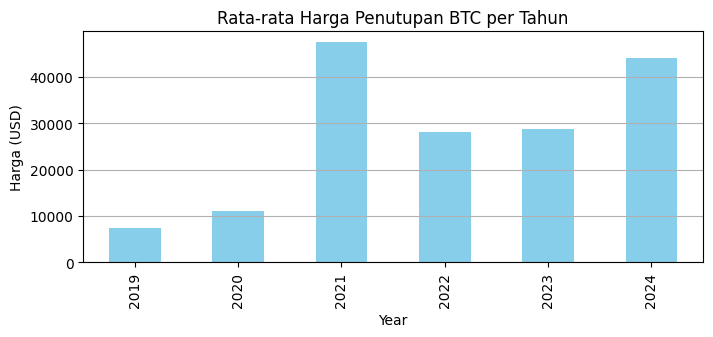

In [ ]:
# Membuat bar chart untuk menunjukkan rata-rata harga per tahun
df_filtered.groupby('Year')['Close'].mean().plot(kind='bar', color='skyblue', figsize=(8,3), title='Rata-rata Harga Penutupan BTC per Tahun')
plt.ylabel('Harga (USD)')  # Label sumbu Y
plt.grid(axis='y')  # Menambahkan grid hanya pada sumbu Y
plt.show()  # Menampilkan grafik

In [ ]:
# Mengelompokkan data berdasarkan tahun dan menghitung harga awal dan akhir tahun
return_tahunan = df_filtered.groupby('Year').agg(
    awal=('Close', 'first'),  # Harga pertama dalam tahun tersebut
    akhir=('Close', 'last')   # Harga terakhir dalam tahun tersebut
)

# Menghitung persentase perubahan harga dari awal tahun ke akhir tahun
return_tahunan['persentase_return'] = ((return_tahunan['akhir'] - return_tahunan['awal']) / return_tahunan['awal']) * 100

# Menampilkan perubahan persentase harga per tahun
return_tahunan

,awal,akhir,persentase_return
Year,,,
2019,3843.520020,7193.599121,87.161745
2020,7200.174316,29001.720703,302.791925
2021,29374.152344,46306.445313,57.643512
2022,47686.812500,16547.496094,-65.299639
2023,16625.080078,42265.187500,154.225467
2024,44167.332031,51841.062500,17.374222


In [ ]:
# Menampilkan statistik deskriptif untuk volume transaksi BTC setiap hari
df_filtered['Volume'].describe()

,Volume
count,1.873000e+03
mean,2.896644e+10
std,1.799846e+10
min,4.324201e+09
25%,1.713058e+10
50%,2.563548e+10
75%,3.620089e+10
max,3.509679e+11


In [ ]:
files.download("BTC_2019_2024_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>